In [47]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
  print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')

Saving Comprehensive_Banking_Database (2).csv to Comprehensive_Banking_Database (2) (1).csv
User uploaded file "Comprehensive_Banking_Database (2) (1).csv" with length 1913340 bytes


In [48]:
import os, re, gc, warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from scipy.stats import zscore


In [49]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [50]:
path = '/content/Comprehensive_Banking_Database (2).csv'

In [51]:
assert os.path.exists(path), f"File not found at {path} - please upload the file."


In [52]:
df = pd.read_csv(path)

In [53]:
df.head()

,Customer ID,First Name,Last Name,Age,Gender,Address,City,Contact Number,Email,Account Type,...,Feedback Type,Resolution Status,Resolution Date,Anomaly,Transaction Description,Merchant Category,KYC Status,KYC Last Updated Date,AML Flag,Account Freeze Flag
0,1.0,Joshua,Hall,45.0,Male,NaN,Fort Worth,19458794854.0,joshua.hall@kag.com,Current,...,Suggestion,Resolved,1/22/2023,1.0,POS - Big Bazaar,Insurance,Expired,2022-01-03,0.0,0.0
1,2.0,Mark,Taylor,47.0,Female,Address_2,Louisville,19458794855.0,mark.taylor@kag.com,Current,...,Complaint,Resolved,8/27/2023,1.0,NEFT Transfer - Rent,NaN,Incomplete,2021-03-06,0.0,0.0
2,3.0,Joseph,Flores,25.0,Female,Address_3,Philadelphia,19458794856.0,joseph.flores@kag.com,Current,...,Praise,Pending,5/11/2023,1.0,UPI - Swiggy,Utilities,Expired,2024-06-05,0.0,0.0
3,4.0,Kevin,Lee,52.0,Other,Address_4,Oklahoma City,19458794857.0,kevin.lee@kag.com,Savings,...,Complaint,Resolved,7/5/2023,1.0,Bill Payment - Electricity,Salary/Income,Expired,2023-01-24,0.0,0.0
4,5.0,Linda,Johnson,68.0,Other,Address_5,Phoenix,19458794858.0,linda.johnson@kag.com,Savings,...,Complaint,Resolved,11/21/2023,1.0,POS - Big Bazaar,Rent,Complete,2025-03-24,0.0,0.0


In [54]:
print("✅ File loaded successfully!")
print("Shape of dataset (rows, columns):", df.shape)

✅ File loaded successfully!
Shape of dataset (rows, columns): (5045, 46)


In [55]:
print("Column names:")
print(df.columns.tolist())

Column names:
['Customer ID', 'First Name', 'Last Name', 'Age', 'Gender', 'Address', 'City', 'Contact Number', 'Email', 'Account Type', 'Account Balance', 'Date Of Account Opening', 'Last Transaction Date', 'TransactionID', 'Transaction Date', 'Transaction Type', 'Transaction Amount', 'Account Balance After Transaction', 'Branch ID', 'Loan ID', 'Loan Amount', 'Loan Type', 'Interest Rate', 'Loan Term', 'Approval/Rejection Date', 'Loan Status', 'CardID', 'Card Type', 'Credit Limit', 'Credit Card Balance', 'Minimum Payment Due', 'Payment Due Date', 'Last Credit Card Payment Date', 'Rewards Points', 'Feedback ID', 'Feedback Date', 'Feedback Type', 'Resolution Status', 'Resolution Date', 'Anomaly', 'Transaction Description', 'Merchant Category', 'KYC Status', 'KYC Last Updated Date', 'AML Flag', 'Account Freeze Flag']


In [56]:
print("\nData types summary:")
print(df.dtypes.value_counts())


Data types summary:
object     33
float64    13
Name: count, dtype: int64


In [57]:
#create a report of all missing value
missing_count = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_report = pd.concat(
    [missing_count, missing_pct],
    axis=1,
    keys=['Missing Values', 'Missing %']
)


In [58]:
print("\n Top columns with missing values:")
missing_report.head(20)


 Top columns with missing values:


,Missing Values,Missing %
City,256,5.074331
Last Credit Card Payment Date,256,5.074331
Customer ID,252,4.995045
Last Transaction Date,249,4.935580
Resolution Date,247,4.895937
Last Name,238,4.717542
KYC Last Updated Date,236,4.677899
Transaction Type,236,4.677899
Approval/Rejection Date,235,4.658077
Merchant Category,234,4.638256


In [59]:
#Standardize Column Names
def clean_col(col):
    col = str(col).strip()
    col = col.replace(' ', '_')
    col = re.sub(r'[^0-9a-zA-Z_]', '', col)
    return col.lower()

original_cols = df.columns.tolist()
df.columns = [clean_col(c) for c in df.columns]

In [60]:
print("Column names standardized!")
print("\nBefore cleaning:\n", original_cols[:10])
print("\nAfter cleaning:\n", df.columns[:10])

Column names standardized!

Before cleaning:
 ['Customer ID', 'First Name', 'Last Name', 'Age', 'Gender', 'Address', 'City', 'Contact Number', 'Email', 'Account Type']

After cleaning:
 Index(['customer_id', 'first_name', 'last_name', 'age', 'gender', 'address',
       'city', 'contact_number', 'email', 'account_type'],
      dtype='object')


In [61]:
#Date parsing
date_cols = [
    'transaction_date',
    'date_of_account_opening',
    'kyc_last_updated_date',
    'last_transaction_date',
    'account_closed_date',
    'resolution_date',
    'approvalrejection_date',
    'payment_due_date'
]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)

In [62]:
# Convert *any* other column containing "date" in its name
for col in df.columns:
    if "date" in col and df[col].dtype == object:
        df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)

In [63]:
print("Date columns converted to datetime format!")

# Quick check(Everything converted to datetime)
for col in df.columns:
    if "date" in col:
        print(f"{col} → {df[col].dtype}, sample values:")
        print(df[col].dropna().head(3).astype(str).tolist())
        print("----")

Date columns converted to datetime format!
date_of_account_opening → datetime64[ns], sample values:
['2006-05-26', '2006-03-02', '2015-07-19']
----
last_transaction_date → datetime64[ns], sample values:
['2023-04-23', '2023-01-27', '2023-01-01']
----
transaction_date → datetime64[ns], sample values:
['2023-07-12', '2023-05-04', '2023-10-08']
----
approvalrejection_date → datetime64[ns], sample values:
['2020-07-30', '2021-01-17', '2022-02-15']
----
payment_due_date → datetime64[ns], sample values:
['2023-11-26', '2023-11-05', '2023-01-08']
----
last_credit_card_payment_date → datetime64[ns], sample values:
['2023-03-20', '2023-06-16', '2023-03-20']
----
feedback_date → datetime64[ns], sample values:
['2023-07-04', '2023-07-09', '2023-12-02']
----
resolution_date → datetime64[ns], sample values:
['2023-01-22', '2023-08-27', '2023-05-11']
----
kyc_last_updated_date → datetime64[ns], sample values:
['2022-03-01', '2021-06-03', '2024-05-06']
----


In [64]:
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Removed {before - after} exact duplicate rows.")

Removed 45 exact duplicate rows.


In [65]:
if 'transaction_id' in df.columns:
    before = df.shape[0]
    df = df.drop_duplicates(subset=['transaction_id'])
    after = df.shape[0]
    print(f"Removed {before - after} duplicate rows based on transaction_id.")

In [66]:
print("Final dataset shape:", df.shape)

Final dataset shape: (5000, 46)


In [67]:
df.head()

,customer_id,first_name,last_name,age,gender,address,city,contact_number,email,account_type,...,feedback_type,resolution_status,resolution_date,anomaly,transaction_description,merchant_category,kyc_status,kyc_last_updated_date,aml_flag,account_freeze_flag
0,1.0,Joshua,Hall,45.0,Male,NaN,Fort Worth,19458794854.0,joshua.hall@kag.com,Current,...,Suggestion,Resolved,2023-01-22,1.0,POS - Big Bazaar,Insurance,Expired,2022-03-01,0.0,0.0
1,2.0,Mark,Taylor,47.0,Female,Address_2,Louisville,19458794855.0,mark.taylor@kag.com,Current,...,Complaint,Resolved,2023-08-27,1.0,NEFT Transfer - Rent,NaN,Incomplete,2021-06-03,0.0,0.0
2,3.0,Joseph,Flores,25.0,Female,Address_3,Philadelphia,19458794856.0,joseph.flores@kag.com,Current,...,Praise,Pending,2023-05-11,1.0,UPI - Swiggy,Utilities,Expired,2024-05-06,0.0,0.0
3,4.0,Kevin,Lee,52.0,Other,Address_4,Oklahoma City,19458794857.0,kevin.lee@kag.com,Savings,...,Complaint,Resolved,2023-07-05,1.0,Bill Payment - Electricity,Salary/Income,Expired,NaT,0.0,0.0
4,5.0,Linda,Johnson,68.0,Other,Address_5,Phoenix,19458794858.0,linda.johnson@kag.com,Savings,...,Complaint,Resolved,2023-11-21,1.0,POS - Big Bazaar,Rent,Complete,NaT,0.0,0.0


In [68]:
print(df.columns.tolist())

['customer_id', 'first_name', 'last_name', 'age', 'gender', 'address', 'city', 'contact_number', 'email', 'account_type', 'account_balance', 'date_of_account_opening', 'last_transaction_date', 'transactionid', 'transaction_date', 'transaction_type', 'transaction_amount', 'account_balance_after_transaction', 'branch_id', 'loan_id', 'loan_amount', 'loan_type', 'interest_rate', 'loan_term', 'approvalrejection_date', 'loan_status', 'cardid', 'card_type', 'credit_limit', 'credit_card_balance', 'minimum_payment_due', 'payment_due_date', 'last_credit_card_payment_date', 'rewards_points', 'feedback_id', 'feedback_date', 'feedback_type', 'resolution_status', 'resolution_date', 'anomaly', 'transaction_description', 'merchant_category', 'kyc_status', 'kyc_last_updated_date', 'aml_flag', 'account_freeze_flag']


In [69]:
#Clean Text Columns
possible_text_cols = [
    'transaction_description',
    'merchant_category',
    'feedback_type',
    'resolution_status'
]

In [70]:
text_cols = [c for c in possible_text_cols if c in df.columns]

In [71]:
def clean_text(x):
    if pd.isnull(x):
        return np.nan
    s = str(x).strip()
    s = s.replace('\n',' ').replace('\r',' ')
    s = re.sub(r'\s+', ' ', s)   # collapse spaces
    s = s.lower()
    if s in ['nan','none','null','']:
        return np.nan
    return s

In [72]:
for col in text_cols:
    df[col] = df[col].apply(clean_text)

In [73]:
print("Cleaned text columns:", text_cols)

if text_cols:
    display(df[text_cols].head(10))

Cleaned text columns: ['transaction_description', 'merchant_category', 'feedback_type', 'resolution_status']


,transaction_description,merchant_category,feedback_type,resolution_status
0,pos - big bazaar,insurance,suggestion,resolved
1,neft transfer - rent,NaN,complaint,resolved
2,upi - swiggy,utilities,praise,pending
3,bill payment - electricity,salary/income,complaint,resolved
4,pos - big bazaar,rent,complaint,resolved
5,pos - flipkart,food & dining,praise,resolved
6,salary from infosys ltd.,rent,complaint,pending
7,pos - big bazaar,rent,complaint,pending
8,upi - swiggy,salary/income,suggestion,NaN
9,bill payment - electricity,insurance,complaint,resolved


In [74]:
# Step 7: Convert Numeric-like Columns

num_like_cols = [
    col for col in df.columns
    if any(word in col for word in ['amount','balance','limit','payment','rate','term','age','points'])
]

print("Numeric-like columns:", num_like_cols)


for col in num_like_cols:
    if df[col].dtype == object:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(',','')
            .str.replace('₹','')
            .str.replace(' ','')
        )
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(" Conversion done!")


df[num_like_cols].info()


Numeric-like columns: ['age', 'account_balance', 'transaction_amount', 'account_balance_after_transaction', 'loan_amount', 'interest_rate', 'loan_term', 'credit_limit', 'credit_card_balance', 'minimum_payment_due', 'payment_due_date', 'last_credit_card_payment_date', 'rewards_points']
 Conversion done!
<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   age                                4786 non-null   float64       
 1   account_balance                    4793 non-null   float64       
 2   transaction_amount                 4778 non-null   float64       
 3   account_balance_after_transaction  4787 non-null   float64       
 4   loan_amount                        4800 non-null   float64       
 5   interest_rate                      4773 non-null   float64       
 6   loan_term            

In [75]:
# Step: Drop unimportant columns

drop_cols = [
    # Personal info (privacy, not predictive)
    'first_name', 'last_name', 'address', 'contact_number', 'email',
]

# Drop only those that exist in df
drop_cols = [c for c in drop_cols if c in df.columns]
df = df.drop(columns=drop_cols)

print("Dropped unimportant columns:", drop_cols)
print("Remaining columns:", df.columns.tolist()[:20], "...")


Dropped unimportant columns: ['first_name', 'last_name', 'address', 'contact_number', 'email']
Remaining columns: ['customer_id', 'age', 'gender', 'city', 'account_type', 'account_balance', 'date_of_account_opening', 'last_transaction_date', 'transactionid', 'transaction_date', 'transaction_type', 'transaction_amount', 'account_balance_after_transaction', 'branch_id', 'loan_id', 'loan_amount', 'loan_type', 'interest_rate', 'loan_term', 'approvalrejection_date'] ...


In [76]:
# Step 8 (Re-run after dropping cols): Handle Missing Values

def add_missing_flag(df, col):
    df[f"{col}_missing_flag"] = df[col].isnull().astype(int)

# Binary flags → numeric, fill missing with 0
for col in ['aml_flag', 'account_freeze_flag']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(0).astype(int)

# Categorical/text → "unknown" + missing flag
for col in ['transaction_description', 'merchant_category', 'kyc_status', 'feedback_type', 'resolution_status']:
    if col in df.columns:
        add_missing_flag(df, col)
        df[col] = df[col].fillna('unknown')

# Date columns → only add missing flag
for col in df.columns:
    if "date" in col:
        add_missing_flag(df, col)

# Numeric → median imputation + missing flag
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    if df[col].isnull().any():
        add_missing_flag(df, col)
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

print("Missing values handled after dropping unimportant columns")

# Quick check: list a few new missing flags
print([c for c in df.columns if 'missing_flag' in c][:15])


Missing values handled after dropping unimportant columns
['transaction_description_missing_flag', 'merchant_category_missing_flag', 'kyc_status_missing_flag', 'feedback_type_missing_flag', 'resolution_status_missing_flag', 'date_of_account_opening_missing_flag', 'last_transaction_date_missing_flag', 'transaction_date_missing_flag', 'approvalrejection_date_missing_flag', 'payment_due_date_missing_flag', 'last_credit_card_payment_date_missing_flag', 'feedback_date_missing_flag', 'resolution_date_missing_flag', 'kyc_last_updated_date_missing_flag', 'customer_id_missing_flag']


In [77]:
# Derive New Features

# Reference "today" date for recency calculations
REF_DATE = pd.Timestamp('2025-09-24')

# Helper: decide if transaction is debit (money out)
def is_debit(txn_type):
    if pd.isnull(txn_type):
        return False
    t = str(txn_type).lower()
    return any(word in t for word in [
        'debit', 'dr', 'withdrawal', 'pos', 'atm', 'payment', 'transfer out', 'upi -', 'debit card', 'paid to'
    ])

# 1) Signed transaction amount
if 'transaction_amount' in df.columns:
    df['transaction_amount'] = pd.to_numeric(df['transaction_amount'], errors='coerce')
    if 'transaction_type' in df.columns:
        df['signed_amount'] = df.apply(
            lambda r: -r['transaction_amount'] if is_debit(r['transaction_type']) else r['transaction_amount'],
            axis=1
        )
    else:
        df['signed_amount'] = df['transaction_amount']

# 2) Days since transaction
if 'transaction_date' in df.columns:
    df['days_since_transaction'] = (REF_DATE - df['transaction_date']).dt.days

# 3) KYC age (days since last update)
if 'kyc_last_updated_date' in df.columns:
    df['kyc_age_days'] = (REF_DATE - df['kyc_last_updated_date']).dt.days

# 4) Account age (days since opening)
if 'date_of_account_opening' in df.columns:
    df['account_age_days'] = (REF_DATE - df['date_of_account_opening']).dt.days

print("Derived features added: signed_amount, days_since_transaction, kyc_age_days, account_age_days")

df[['transaction_type','transaction_amount','signed_amount','transaction_date','days_since_transaction','kyc_last_updated_date','kyc_age_days','account_age_days']].head(10)


Derived features added: signed_amount, days_since_transaction, kyc_age_days, account_age_days


,transaction_type,transaction_amount,signed_amount,transaction_date,days_since_transaction,kyc_last_updated_date,kyc_age_days,account_age_days
0,Withdrawal,1457.61,-1457.61,2023-07-12,805.0,2022-03-01,1303.0,7061.0
1,Deposit,1660.99,-1660.99,NaT,NaN,2021-06-03,1574.0,7146.0
2,Deposit,839.91,-839.91,2023-05-04,874.0,2024-05-06,506.0,3720.0
3,Withdrawal,4908.89,-4908.89,NaT,NaN,NaT,NaN,6447.0
4,Transfer,589.07,589.07,NaT,NaN,NaT,NaN,1583.0
5,Withdrawal,4914.67,-4914.67,NaT,NaN,NaT,NaN,3565.0
6,Deposit,3534.90,-3534.90,NaT,NaN,NaT,NaN,1175.0
7,Deposit,454.87,-454.87,2023-10-08,717.0,NaT,NaN,1015.0
8,Withdrawal,768.56,-768.56,NaT,NaN,NaT,NaN,4896.0
9,Deposit,1641.59,-1641.59,NaT,NaN,2025-05-03,144.0,1374.0


In [78]:
# Step 10: Handle Outliers (Winsorize at 1% and 99%)

# Select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Cap each numeric column at 1st and 99th percentiles
for col in numeric_cols:
    low = df[col].quantile(0.01)
    high = df[col].quantile(0.99)
    if pd.notnull(low) and pd.notnull(high) and low < high:
        df[col] = df[col].clip(lower=low, upper=high)

print(" Outliers capped at 1% and 99% quantiles")

# Quick check
df[numeric_cols].describe().T.head(10)


 Outliers capped at 1% and 99% quantiles


,count,mean,std,min,25%,50%,75%,max
customer_id,5000.0,2501.634600,1408.708014,51.9900,1319.7500,2506.000,3689.5000,4949.0100
age,5000.0,43.394800,14.815506,18.0000,31.0000,43.000,56.0000,69.0000
account_balance,5000.0,5056.662223,2790.353515,210.7953,2683.1975,5065.190,7414.9575,9903.7682
transactionid,5000.0,2501.108800,1411.642343,55.9900,1302.7500,2506.000,3699.2500,4946.0100
transaction_amount,5000.0,2507.977730,1415.200454,61.6673,1305.9475,2498.995,3732.3575,4949.9105
account_balance_after_transaction,5000.0,5060.091388,3948.689336,-3507.5813,2236.7525,5100.250,7906.5325,13557.4597
branch_id,5000.0,50.621400,27.914525,1.0000,27.0000,50.000,74.0000,99.0000
loan_id,5000.0,2499.453600,1416.598017,51.9900,1295.7500,2498.000,3702.2500,4949.0100
loan_amount,5000.0,25487.950733,13743.249707,1440.4250,13846.9625,25915.595,36781.3975,49511.1163
interest_rate,5000.0,5.509518,2.569707,1.0700,3.3000,5.520,7.7600,9.9000


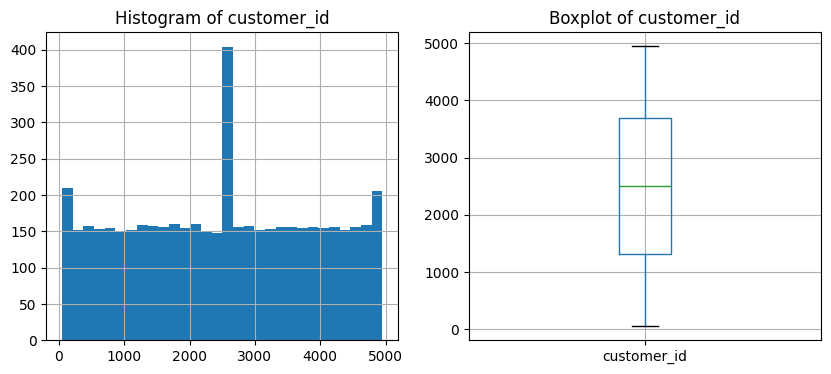

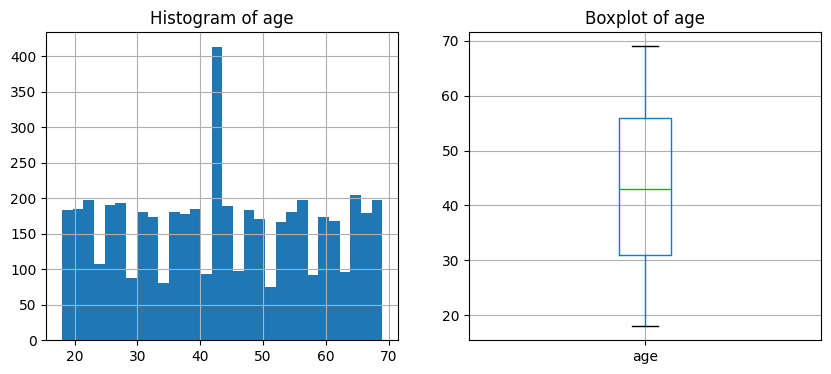

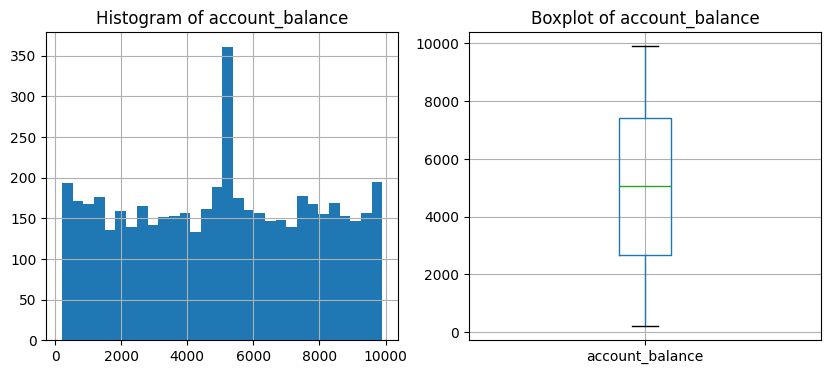

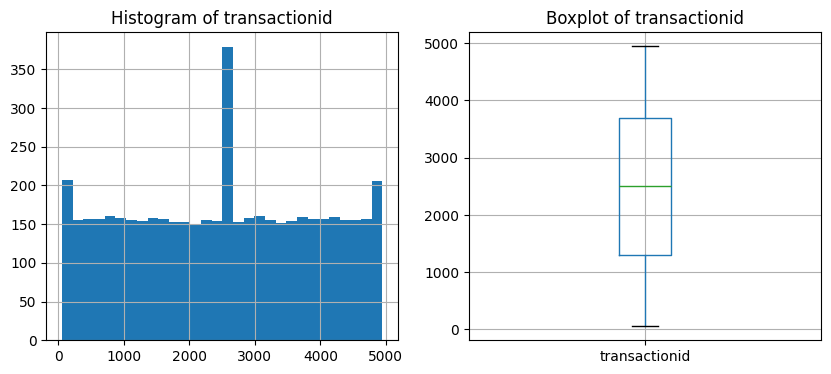

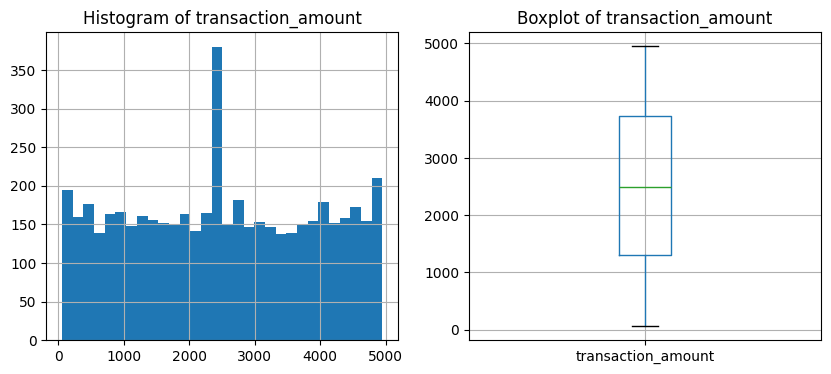

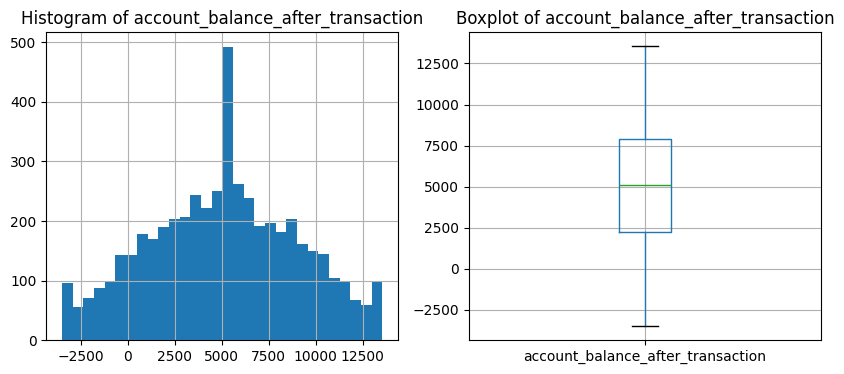

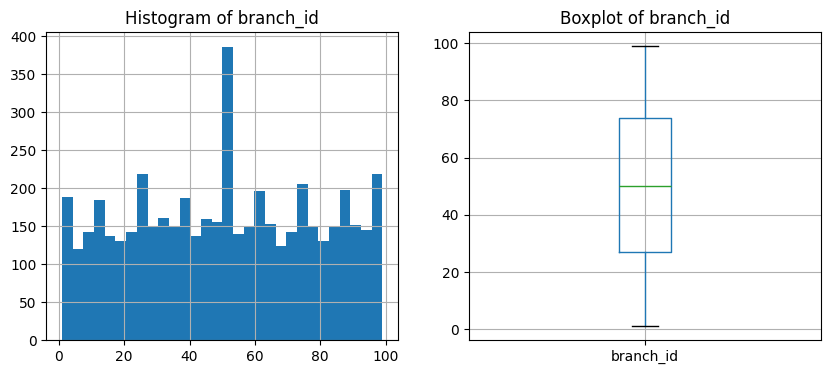

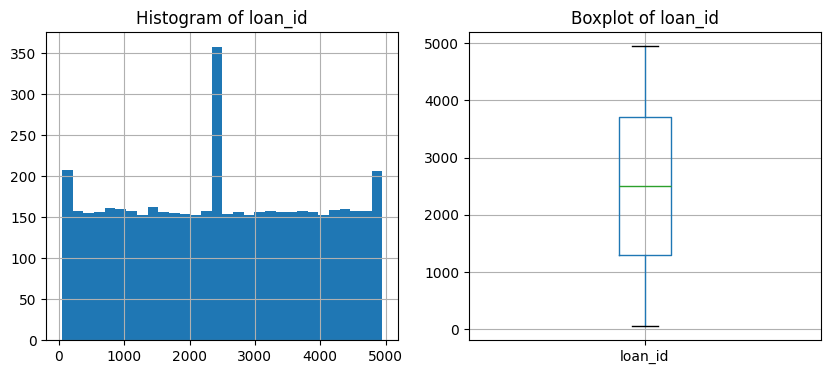

In [79]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()


# 1. Check distributions (histograms + boxplots)
for col in numeric_cols[:8]:  # first 8 numeric cols for preview
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    df[col].hist(bins=30)
    plt.title(f"Histogram of {col}")

    plt.subplot(1,2,2)
    df.boxplot(column=col)
    plt.title(f"Boxplot of {col}")
    plt.show()

In [80]:
# 2. IQR method

outlier_report = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    outlier_report[col] = {"IQR_Lower": lower, "IQR_Upper": upper, "Outliers": outliers}

print(" Outlier detection using IQR:")
for k,v in outlier_report.items():
    print(f"{k}: {v['Outliers']} outliers")

 Outlier detection using IQR:
customer_id: 0 outliers
age: 0 outliers
account_balance: 0 outliers
transactionid: 0 outliers
transaction_amount: 0 outliers
account_balance_after_transaction: 0 outliers
branch_id: 0 outliers
loan_id: 0 outliers
loan_amount: 0 outliers
interest_rate: 0 outliers
loan_term: 0 outliers
cardid: 0 outliers
credit_limit: 0 outliers
credit_card_balance: 0 outliers
minimum_payment_due: 0 outliers
rewards_points: 0 outliers
feedback_id: 0 outliers
aml_flag: 485 outliers
account_freeze_flag: 240 outliers
transaction_description_missing_flag: 210 outliers
merchant_category_missing_flag: 231 outliers
kyc_status_missing_flag: 202 outliers
feedback_type_missing_flag: 186 outliers
resolution_status_missing_flag: 226 outliers
date_of_account_opening_missing_flag: 221 outliers
last_transaction_date_missing_flag: 254 outliers
transaction_date_missing_flag: 0 outliers
approvalrejection_date_missing_flag: 239 outliers
payment_due_date_missing_flag: 226 outliers
last_credit_c

In [81]:
outlier_summary = []

# Loop through all numeric columns
for col in df.select_dtypes(include=[np.number]).columns:
    if df[col].dropna().shape[0] < 10:  # skip columns with very few values
        continue

    # IQR Method
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    iqr_outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    # Z-score Method
    z_scores = np.abs(zscore(df[col].dropna()))
    z_outliers = (z_scores > 3).sum()

    # Save results
    outlier_summary.append({
        "Feature": col,
        "IQR Lower": round(lower, 2),
        "IQR Upper": round(upper, 2),
        "IQR Outliers": int(iqr_outliers),
        "Z-score Outliers": int(z_outliers)
    })

# Convert to DataFrame for easy view
outlier_df = pd.DataFrame(outlier_summary).sort_values(by="IQR Outliers", ascending=False)

# Display
print("Outlier Summary Report:")
display(outlier_df)

Outlier Summary Report:


,Feature,IQR Lower,IQR Upper,IQR Outliers,Z-score Outliers
17,aml_flag,0.00,0.00,485,485
25,last_transaction_date_missing_flag,0.00,0.00,254,254
29,last_credit_card_payment_date_missing_flag,0.00,0.00,254,254
31,resolution_date_missing_flag,0.00,0.00,250,250
33,customer_id_missing_flag,0.00,0.00,247,247
18,account_freeze_flag,0.00,0.00,240,240
27,approvalrejection_date_missing_flag,0.00,0.00,239,239
20,merchant_category_missing_flag,0.00,0.00,231,231
43,loan_term_missing_flag,0.00,0.00,228,228
42,interest_rate_missing_flag,0.00,0.00,227,227


In [82]:
# Aggregate to customer-level features(Because we have transaction we have to aggregate )

# Identify customer id column
cust_col = 'customer_id'  # we keep this as our main identifier

# Reference date for recency
REF_DATE = pd.Timestamp('2025-09-24')

# Base aggregation
customers = df.groupby(cust_col).agg(
    last_transaction_date=('transaction_date', 'max'),
    first_transaction_date=('transaction_date', 'min'),
    total_txn_count=('transaction_amount', 'count')
).reset_index()

# Recency feature
customers['days_since_last_txn'] = (REF_DATE - customers['last_transaction_date']).dt.days

# Step 11: Aggregate to customer-level features

# Identify customer id column
cust_col = 'customer_id'  # keep this as main identifier

# Use dataset max transaction date as reference date
REF_DATE = df['transaction_date'].max()
print("Reference date set to:", REF_DATE)

# Base aggregation
customers = df.groupby(cust_col).agg(
    last_transaction_date=('transaction_date', 'max'),
    first_transaction_date=('transaction_date', 'min'),
    total_txn_count=('transaction_amount', 'count')
).reset_index()

# Recency feature
customers['days_since_last_txn'] = (REF_DATE - customers['last_transaction_date']).dt.days

# Transactions in last 90 and 30 days
txn_90d = df[df['transaction_date'] >= (REF_DATE - pd.Timedelta(days=90))] \
    .groupby(cust_col).size().rename('txn_count_90d').reset_index()

txn_30d = df[df['transaction_date'] >= (REF_DATE - pd.Timedelta(days=30))] \
    .groupby(cust_col).size().rename('txn_count_30d').reset_index()

customers = customers.merge(txn_90d, on=cust_col, how='left') \
                     .merge(txn_30d, on=cust_col, how='left')

customers[['txn_count_90d','txn_count_30d']] = customers[['txn_count_90d','txn_count_30d']].fillna(0)

# Frequency per month (approx from 90 days)
customers['txn_freq_per_month_90d'] = customers['txn_count_90d'] / 3.0

# Average transaction amounts (30d and 90d)
avg_txn_90d = df[df['transaction_date'] >= (REF_DATE - pd.Timedelta(days=90))] \
    .groupby(cust_col)['transaction_amount'].mean().rename('avg_txn_amt_90d').reset_index()

avg_txn_30d = df[df['transaction_date'] >= (REF_DATE - pd.Timedelta(days=30))] \
    .groupby(cust_col)['transaction_amount'].mean().rename('avg_txn_amt_30d').reset_index()

customers = customers.merge(avg_txn_90d, on=cust_col, how='left') \
                     .merge(avg_txn_30d, on=cust_col, how='left')

customers[['avg_txn_amt_90d','avg_txn_amt_30d']] = customers[['avg_txn_amt_90d','avg_txn_amt_30d']].fillna(0)

print("✅ Customer-level features created successfully")
customers.head(10)



Reference date set to: 2023-12-12 00:00:00
✅ Customer-level features created successfully


,customer_id,last_transaction_date,first_transaction_date,total_txn_count,days_since_last_txn,txn_count_90d,txn_count_30d,txn_freq_per_month_90d,avg_txn_amt_90d,avg_txn_amt_30d
0,51.99,2023-12-10,2023-01-07,50,2.0,6.0,4.0,2.000000,1929.590833,2513.20125
1,52.00,NaT,NaT,1,NaN,0.0,0.0,0.000000,0.000000,0.00000
2,53.00,2023-10-11,2023-10-11,1,62.0,1.0,0.0,0.333333,2498.995000,0.00000
3,54.00,2023-04-07,2023-04-07,1,249.0,0.0,0.0,0.000000,0.000000,0.00000
4,56.00,2023-08-02,2023-08-02,1,132.0,0.0,0.0,0.000000,0.000000,0.00000
5,57.00,NaT,NaT,1,NaN,0.0,0.0,0.000000,0.000000,0.00000
6,58.00,2023-02-01,2023-02-01,1,314.0,0.0,0.0,0.000000,0.000000,0.00000
7,59.00,NaT,NaT,1,NaN,0.0,0.0,0.000000,0.000000,0.00000
8,60.00,NaT,NaT,1,NaN,0.0,0.0,0.000000,0.000000,0.00000
9,61.00,NaT,NaT,1,NaN,0.0,0.0,0.000000,0.000000,0.00000


In [83]:
print("Min transaction date:", df['transaction_date'].min())
print("Max transaction date:", df['transaction_date'].max())


Min transaction date: 2023-01-01 00:00:00
Max transaction date: 2023-12-12 00:00:00


In [84]:
from sklearn.preprocessing import LabelEncoder

In [85]:
# 1) Identify categorical columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns found:", cat_cols)

Categorical columns found: ['gender', 'city', 'account_type', 'transaction_type', 'loan_type', 'loan_status', 'card_type', 'feedback_type', 'resolution_status', 'anomaly', 'transaction_description', 'merchant_category', 'kyc_status']


In [86]:
# 2) Label Encoding for binary/simple columns
le = LabelEncoder()
for col in cat_cols:
    if df[col].nunique() == 2:  # only 2 categories → safe to label encode
        df[col] = le.fit_transform(df[col].astype(str))

# 3) One-Hot Encoding for multi-category columns
df = pd.get_dummies(df, columns=[col for col in cat_cols if df[col].nunique() > 2], drop_first=True)

print("Encoding complete. New shape:", df.shape)
df.head(10)

Encoding complete. New shape: (5000, 166)


,customer_id,age,account_balance,date_of_account_opening,last_transaction_date,transactionid,transaction_date,transaction_amount,account_balance_after_transaction,branch_id,...,merchant_category_shopping,merchant_category_unknown,merchant_category_utilities,kyc_status_ERR,kyc_status_Expired,kyc_status_INCOMPLETE,kyc_status_Incomplete,kyc_status_UNKNOWN,kyc_status_incomplete,kyc_status_unknown
0,51.99,45.0,1313.38,2006-05-26,2023-04-23,55.99,2023-07-12,1457.61,2770.99,50.0,...,False,False,False,False,True,False,False,False,False,False
1,51.99,47.0,5988.46,2006-03-02,2023-01-27,55.99,NaT,1660.99,7649.45,63.0,...,False,True,False,False,False,False,True,False,False,False
2,51.99,25.0,8277.88,2015-07-19,2023-01-01,55.99,2023-05-04,839.91,7437.97,82.0,...,False,False,True,False,True,False,False,False,False,False
3,51.99,52.0,7487.21,2008-01-30,2023-08-02,55.99,NaT,4908.89,12396.10,41.0,...,False,False,False,False,True,False,False,False,False,False
4,51.99,68.0,6993.55,2021-05-25,2023-03-27,55.99,NaT,589.07,6404.48,9.0,...,False,False,False,False,False,False,False,False,False,False
5,51.99,43.0,9295.64,2015-12-21,2023-06-04,55.99,NaT,4914.67,4380.97,20.0,...,False,False,False,False,True,False,False,False,False,False
6,51.99,43.0,4005.72,2022-07-07,2023-03-21,55.99,NaT,3534.90,470.82,21.0,...,False,False,False,False,False,False,False,False,False,False
7,51.99,47.0,1458.45,2022-12-14,2023-03-01,55.99,2023-10-08,454.87,1003.58,25.0,...,False,False,False,False,False,False,True,False,False,False
8,51.99,52.0,1109.30,2012-04-29,2023-11-05,55.99,NaT,768.56,340.74,66.0,...,False,False,False,False,False,False,False,False,False,True
9,51.99,55.0,9554.62,2021-12-20,2023-02-05,55.99,NaT,1641.59,11196.21,30.0,...,False,False,False,False,False,False,True,False,False,False


In [87]:
#Scale numeric features
from sklearn.preprocessing import StandardScaler

In [88]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Exclude identifiers like customer_id if still present
num_cols = [col for col in num_cols if col not in ['customer_id']]

print("Numeric columns to scale:", num_cols[:10])



Numeric columns to scale: ['age', 'account_balance', 'transactionid', 'transaction_amount', 'account_balance_after_transaction', 'branch_id', 'loan_id', 'loan_amount', 'interest_rate', 'loan_term']


In [89]:
# Initialize scaler
scaler = StandardScaler()

# Fit + transform
df[num_cols] = scaler.fit_transform(df[num_cols])

print("Scaling complete. All numeric features standardized.")
df.head(10)

Scaling complete. All numeric features standardized.


,customer_id,age,account_balance,date_of_account_opening,last_transaction_date,transactionid,transaction_date,transaction_amount,account_balance_after_transaction,branch_id,...,merchant_category_shopping,merchant_category_unknown,merchant_category_utilities,kyc_status_ERR,kyc_status_Expired,kyc_status_INCOMPLETE,kyc_status_Incomplete,kyc_status_UNKNOWN,kyc_status_incomplete,kyc_status_unknown
0,51.99,0.108357,-1.341642,2006-05-26,2023-04-23,-1.732283,2023-07-12,-0.742278,-0.579770,-0.022263,...,False,False,False,False,True,False,False,False,False,False
1,51.99,0.243364,0.333969,2006-03-02,2023-01-27,-1.732283,NaT,-0.598553,0.655817,0.443491,...,False,True,False,False,False,False,True,False,False,False
2,51.99,-1.241715,1.154528,2015-07-19,2023-01-01,-1.732283,2023-05-04,-1.178797,0.602255,1.124208,...,False,False,True,False,True,False,False,False,False,False
3,51.99,0.580882,0.871141,2008-01-30,2023-08-02,-1.732283,NaT,1.696687,1.858020,-0.344708,...,False,False,False,False,True,False,False,False,False,False
4,51.99,1.660940,0.694206,2021-05-25,2023-03-27,-1.732283,NaT,-1.356062,0.340499,-1.491179,...,False,False,False,False,False,False,False,False,False,False
5,51.99,-0.026650,1.519306,2015-12-21,2023-06-04,-1.732283,NaT,1.700772,-0.172004,-1.097080,...,False,False,False,False,True,False,False,False,False,False
6,51.99,-0.026650,-0.376672,2022-07-07,2023-03-21,-1.732283,NaT,0.725710,-1.162343,-1.061253,...,False,False,False,False,False,False,False,False,False,False
7,51.99,0.243364,-1.289647,2022-12-14,2023-03-01,-1.732283,2023-10-08,-1.450899,-1.027409,-0.917944,...,False,False,False,False,False,False,True,False,False,False
8,51.99,0.580882,-1.414787,2012-04-29,2023-11-05,-1.732283,NaT,-1.229219,-1.195289,0.550973,...,False,False,False,False,False,False,False,False,False,True
9,51.99,0.783393,1.612128,2021-12-20,2023-02-05,-1.732283,NaT,-0.612263,1.554119,-0.738808,...,False,False,False,False,False,False,True,False,False,False


In [90]:
# Train/Test Split
from sklearn.model_selection import train_test_split

In [91]:
# Define features (X) and target (y)
X = df.drop(columns=['churn_flag'], errors='ignore')
y = df['churn_flag'] if 'churn_flag' in df.columns else None

# Check if target exists
if y is None:
    print("No churn_flag found. We will need to create it in the next step.")
else:
    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print("Train/Test Split complete")
    print("Train size:", X_train.shape, "Test size:", X_test.shape)


No churn_flag found. We will need to create it in the next step.


In [102]:
customers['churn_flag'] = (
    (
        (customers['days_since_last_txn'] > 180)   # inactive for 6 months
        & (customers['txn_count_90d'] < 2)         # almost no transactions recently
    )
    | ((customers['avg_txn_amt_90d'] == 0) & (customers['days_since_last_txn'] > 180))  # truly inactive
    | ((customers['txn_count_90d'] == 0) & (customers['avg_txn_amt_30d'] == 0) & (customers['days_since_last_txn'] > 180))
).astype(int)

print(customers['churn_flag'].value_counts(normalize=True))

churn_flag
0    0.800644
1    0.199356
Name: proportion, dtype: float64


In [103]:
customers['churn_flag'].value_counts(normalize=True)

,proportion
churn_flag,
0,0.800644
1,0.199356


In [126]:
# -----------------------------
# STEP 1: Define Features (X), Target (y), and Save Customer IDs
# -----------------------------
cust_ids = customers['customer_id']   # keep IDs for later reporting
y = customers['churn_flag']           # target variable

# Features = everything except churn_flag + customer_id
X = customers.drop(columns=['churn_flag', 'customer_id'], errors='ignore')

print("✅ Step 1 Complete")
print("X shape:", X.shape)
print("y distribution:\n", y.value_counts(normalize=True))

# -----------------------------
# STEP 2: Train/Test Split
# -----------------------------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, cust_train, cust_test = train_test_split(
    X, y, cust_ids, test_size=0.2, stratify=y, random_state=42
)

print("\n✅ Step 2 Complete")
print("Train size:", X_train.shape, "Test size:", X_test.shape)
print("Train churn ratio:\n", y_train.value_counts(normalize=True))
print("Test churn ratio:\n", y_test.value_counts(normalize=True))

# -----------------------------
# STEP 3: Remove Leakage Columns & Handle Missing Values
# -----------------------------
# Drop datetime and leakage columns
drop_cols = ['last_transaction_date', 'first_transaction_date', 'days_since_last_txn']

X_train_noleak = X_train.drop(columns=drop_cols, errors='ignore').fillna(0)
X_test_noleak  = X_test.drop(columns=drop_cols, errors='ignore').fillna(0)

print("\n✅ Step 3 Complete")
print("Final feature columns used:", X_train_noleak.columns.tolist())

# -----------------------------
# STEP 4: Train Logistic Regression + Evaluate
# -----------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Train model
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_noleak, y_train)

# Predictions
y_pred = log_reg.predict(X_test_noleak)
y_prob = log_reg.predict_proba(X_test_noleak)[:, 1]

print("\n✅ Step 4: Model Trained and Predictions Done")



✅ Step 1 Complete
X shape: (4655, 9)
y distribution:
 churn_flag
0    0.800644
1    0.199356
Name: proportion, dtype: float64

✅ Step 2 Complete
Train size: (3724, 9) Test size: (931, 9)
Train churn ratio:
 churn_flag
0    0.800752
1    0.199248
Name: proportion, dtype: float64
Test churn ratio:
 churn_flag
0    0.800215
1    0.199785
Name: proportion, dtype: float64

✅ Step 3 Complete
Final feature columns used: ['total_txn_count', 'txn_count_90d', 'txn_count_30d', 'txn_freq_per_month_90d', 'avg_txn_amt_90d', 'avg_txn_amt_30d']

✅ Step 4: Model Trained and Predictions Done


In [127]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))



Confusion Matrix:
 [[ 98 647]
 [  0 186]]


In [128]:
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))



Classification Report:
               precision    recall  f1-score   support

           0     1.0000    0.1315    0.2325       745
           1     0.2233    1.0000    0.3651       186

    accuracy                         0.3050       931
   macro avg     0.6116    0.5658    0.2988       931
weighted avg     0.8448    0.3050    0.2590       931



In [130]:
print("\nROC-AUC Score:", round(roc_auc_score(y_test, y_prob), 4))


ROC-AUC Score: 0.5658


In [131]:
print(X.columns.tolist())

['last_transaction_date', 'first_transaction_date', 'total_txn_count', 'days_since_last_txn', 'txn_count_90d', 'txn_count_30d', 'txn_freq_per_month_90d', 'avg_txn_amt_90d', 'avg_txn_amt_30d']
